# 09. Modelos Autorregresivos Areales — Predicción de Altiplanos

Implementación de **todos los modelos autorregresivos espaciales** de la Sección 3 del
libro guía (Áreas), adaptados a la clasificación binaria de Altiplanos sobre **celdas
de 5 km** (2,596 celdas válidas).

**Enfoque:** Modelo de Probabilidad Lineal (LPM) — la variable binaria Altiplano (0/1)
se trata como continua para usar los estimadores ML/GMM de `spreg`. Las predicciones se
recortan a [0,1] para interpretarlas como probabilidades.

**Modelos implementados:**

| Modelo | Ecuación | Estimador spreg | Parámetro espacial |
|---|---|---|---|
| OLS | $y = X\beta + \varepsilon$ | `OLS` | — |
| SLX | $y = X\beta + WX\gamma + \varepsilon$ | `OLS` (con WX) | $\gamma$ |
| SAR | $y = \rho Wy + X\beta + \varepsilon$ | `ML_Lag` | $\rho$ |
| SEM | $y = X\beta + u,\ u = \lambda Wu + \varepsilon$ | `ML_Error` | $\lambda$ |
| SDM (Durbin) | $y = \rho Wy + X\beta + WX\gamma + \varepsilon$ | `ML_Lag` + WX | $\rho, \gamma$ |
| SDEM | $y = X\beta + WX\gamma + u,\ u = \lambda Wu + \varepsilon$ | `ML_Error` + WX | $\lambda, \gamma$ |
| SAC (SARAR) | $y = \rho Wy + X\beta + u,\ u = \lambda Wu + \varepsilon$ | `GM_Combo_Het` | $\rho, \lambda$ |
| GNS | $y = \rho Wy + X\beta + WX\gamma + u,\ u = \lambda Wu + \varepsilon$ | `GM_Combo_Het` + WX | $\rho, \lambda, \gamma$ |

**Variables rezagadas (SLX):** solo las topográficas (altitud, pendiente, relieve).
Las dummies de región NO se rezagan (son indicadores fijos de zona, no tienen
continuidad espacial).

## 1. Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import time, os, sys, warnings
warnings.filterwarnings('ignore')

import spreg
from spreg import OLS, ML_Lag, ML_Error, GM_Combo_Het
import libpysal
from libpysal.weights import W, lag_spatial
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)

SEMILLA = 42
np.random.seed(SEMILLA)

BASE = r'C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial'
GPKG_IN = os.path.join(BASE, 'Resultados', 'celdas_car_v2.gpkg')
RES_DIR = os.path.join(BASE, 'Resultados', '09_autorregresivos_areales_v2')
IMG_DIR = os.path.join(BASE, 'Imágenes', '09_autorregresivos_areales_v2')
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)
sys.path.insert(0, os.path.join(BASE, 'Codigo'))

print(f'spreg {spreg.__version__}')
print(f'libpysal {libpysal.__version__}')
print(f'SEMILLA = {SEMILLA}')

spreg 1.9.0
libpysal 4.14.2.dev39+g33e173b30
SEMILLA = 42


## 2. Carga de datos

Las celdas de 5 km provienen de `celdas_car_v2.gpkg` (generadas en el notebook 11 —
CAR). Cada celda contiene:
- **y:** Altiplano binario (1 si ≥25% de los píxeles de 50 m son Altiplano)
- **altitud, pendiente, relieve:** medias zonales estandarizables
- **region:** zona del clustering (0–3)
- **row, col:** posición en la grilla regular (para construir adyacencia Rook)

In [2]:
gdf = gpd.read_file(GPKG_IN)
gdf = gdf.reset_index(drop=True)
print(f'Celdas: {len(gdf)}')
print(f'Altiplano=1: {int(gdf["y"].sum())} ({gdf["y"].mean()*100:.1f}%)')
print(f'CRS: {gdf.crs}')

region_names = {
    0: 'C. Central - Magdalena',
    1: 'C. Occidental - Farallones',
    2: 'C. Occidental - Atrato',
    3: 'C. Central - Altiplanos'
}
print('\nRegiones:')
for k, v in sorted(gdf['region'].value_counts().items()):
    print(f'  {int(k)}: {region_names[int(k)]} — {v} celdas')

# --- Adyacencia Rook desde row/col ---
pos_to_idx = {}
for i, r in gdf.iterrows():
    pos_to_idx[(int(r['row']), int(r['col']))] = i

neighbors = {}
for i, r in gdf.iterrows():
    nbrs = []
    ri, ci = int(r['row']), int(r['col'])
    for dr, dc in [(0,1), (0,-1), (1,0), (-1,0)]:
        key = (ri + dr, ci + dc)
        if key in pos_to_idx:
            nbrs.append(pos_to_idx[key])
    neighbors[i] = nbrs

w = W(neighbors)
w.transform = 'r'
print(f'\nPesos Rook: {w.n} celdas, {int(w.s0)} aristas, grado medio {w.mean_neighbors:.2f}')
print(f'Islas: {len(w.islands)}')

Celdas: 2596
Altiplano=1: 558 (21.5%)
CRS: EPSG:32618

Regiones:
  0: C. Central - Magdalena — 1140 celdas
  1: C. Occidental - Farallones — 642 celdas
  2: C. Occidental - Atrato — 262 celdas
  3: C. Central - Altiplanos — 552 celdas



Pesos Rook: 2596 celdas, 2596 aristas, grado medio 3.86
Islas: 0


## 3. Exploración de datos

=== Estadísticas descriptivas ===
             y  altitud  pendiente  relieve   region
count  2596.00  2596.00    2596.00  2596.00  2596.00
mean      0.21  1198.56      18.48   151.77     1.09
std       0.41   748.00       5.99    60.38     1.18
min       0.00    49.35       3.34    23.61     0.00
25%       0.00   561.75      13.95   104.99     0.00
50%       0.00  1027.68      17.71   142.82     1.00
75%       0.00  1752.02      23.03   195.00     2.00
max       1.00  3417.49      34.47   353.49     3.00


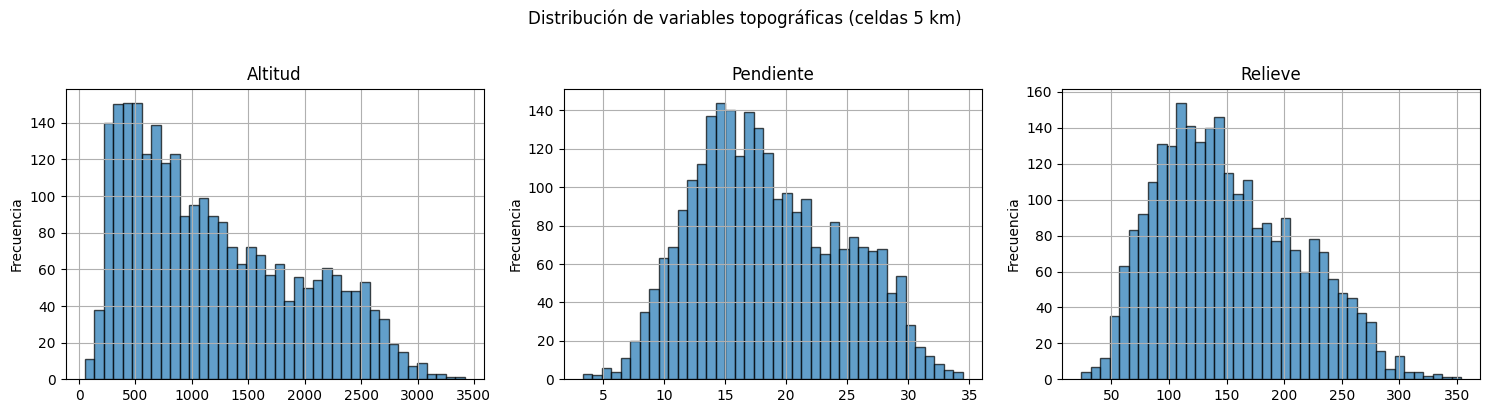


Proporción de Altiplano por región:
  Región 0: 28.1% (320/1140)
  Región 1: 0.2% (1/642)
  Región 2: 16.4% (43/262)
  Región 3: 35.1% (194/552)


In [3]:
print('=== Estadísticas descriptivas ===')
print(gdf[['y', 'altitud', 'pendiente', 'relieve', 'region']].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['altitud', 'pendiente', 'relieve']):
    gdf[col].hist(bins=40, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col.capitalize())
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de variables topográficas (celdas 5 km)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '00_histogramas.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nProporción de Altiplano por región:')
for reg in sorted(gdf['region'].unique()):
    sub = gdf[gdf['region'] == reg]
    print(f'  Región {int(reg)}: {sub["y"].mean()*100:.1f}% ({int(sub["y"].sum())}/{len(sub)})')

### Mapa de celdas — Altiplano observado

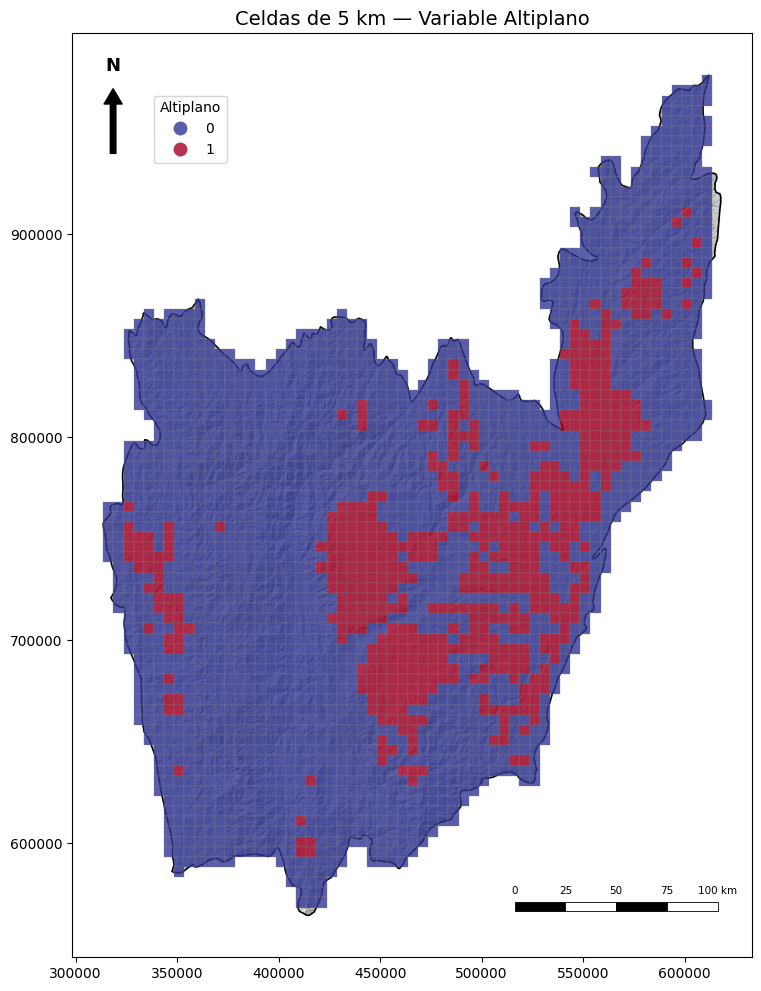

In [4]:
from plantilla_mapas import aplicar_plantilla_mapa, posicionar_leyenda

fig, ax = plt.subplots(figsize=(10, 12))
ancla = aplicar_plantilla_mapa(ax)
gdf.plot(column='y', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
         linewidth=0.3, alpha=0.8, zorder=5, categorical=True,
         legend=True,
         legend_kwds=posicionar_leyenda(ax, ancla, titulo='Altiplano'))
ax.set_title('Celdas de 5 km — Variable Altiplano', fontsize=14)
plt.savefig(os.path.join(RES_DIR, '01_mapa_celdas_altiplano.png'),
            dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(IMG_DIR, '01_mapa_celdas_altiplano.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Preparación de datos

- **Estandarización:** altitud, pendiente y relieve se escalan a media=0, std=1.
- **Dummies de región:** 3 dummies para 4 zonas (referencia: Región 0 — C. Central -
  Magdalena). Esto incorpora la heterogeneidad zonal, análogo al enfoque GWR/jerárquico.
- **Rezago espacial (WX):** solo de las 3 variables topográficas. Las dummies de región
  NO se rezagan porque representan zonas contiguas ya definidas, no gradientes continuos.
- La constante NO se incluye en X — `spreg` la agrega internamente.

In [5]:
scaler = StandardScaler()
X_topo = scaler.fit_transform(gdf[['altitud', 'pendiente', 'relieve']].values)

region_dummies = pd.get_dummies(gdf['region'].astype(int),
                                prefix='region', drop_first=True).values.astype(float)

X = np.hstack([X_topo, region_dummies])
y = gdf['y'].values.reshape(-1, 1)

feat_names = ['altitud_s', 'pendiente_s', 'relieve_s',
              'region_1', 'region_2', 'region_3']
TOPO_IDX = [0, 1, 2]

print(f'X shape: {X.shape} — {feat_names}')
print(f'y shape: {y.shape}')

WX_topo = np.column_stack([lag_spatial(w, X[:, i]) for i in TOPO_IDX])
feat_wx = ['W_altitud_s', 'W_pendiente_s', 'W_relieve_s']

X_aug = np.hstack([X, WX_topo])
feat_aug = feat_names + feat_wx
print(f'X_aug shape: {X_aug.shape} — {feat_aug}')
print(f'\nVariables con rezago espacial: {feat_wx}')
print('Variables SIN rezago: region_1, region_2, region_3')

X shape: (2596, 6) — ['altitud_s', 'pendiente_s', 'relieve_s', 'region_1', 'region_2', 'region_3']
y shape: (2596, 1)
X_aug shape: (2596, 9) — ['altitud_s', 'pendiente_s', 'relieve_s', 'region_1', 'region_2', 'region_3', 'W_altitud_s', 'W_pendiente_s', 'W_relieve_s']

Variables con rezago espacial: ['W_altitud_s', 'W_pendiente_s', 'W_relieve_s']
Variables SIN rezago: region_1, region_2, region_3


## 5. Función auxiliar de evaluación

Cada modelo produce predicciones continuas (LPM). La función:
1. Recorta predicciones a [0,1] para interpretarlas como probabilidades
2. Clasifica con umbral=0.5
3. Calcula AUC-ROC, Accuracy, F1, Precision, Recall
4. Almacena resultados para la comparación final

In [6]:
resultados = []

def evaluar_modelo(model, y_true, nombre):
    predy = model.predy.flatten()
    prob = np.clip(predy, 0, 1)
    pred_class = (prob >= 0.5).astype(int)
    y_flat = y_true.flatten()

    auc = roc_auc_score(y_flat, prob)
    acc = accuracy_score(y_flat, pred_class)
    f1 = f1_score(y_flat, pred_class)
    prec = precision_score(y_flat, pred_class)
    rec = recall_score(y_flat, pred_class)
    cm = confusion_matrix(y_flat, pred_class)

    logll = getattr(model, 'logll', None)
    aic_v = getattr(model, 'aic', None)
    bic_v = getattr(model, 'schwarz', None)

    print(f'\n{"="*60}')
    print(f'  {nombre} — Métricas de clasificación (LPM, umbral=0.5)')
    print(f'{"="*60}')
    if logll is not None:
        print(f'  Log-Likelihood: {logll:.2f}')
        print(f'  AIC:            {aic_v:.2f}')
        print(f'  BIC (Schwarz):  {bic_v:.2f}')
    print(f'  AUC-ROC:        {auc:.4f}')
    print(f'  Accuracy:       {acc:.4f}')
    print(f'  F1-Score:       {f1:.4f}')
    print(f'  Precision:      {prec:.4f}')
    print(f'  Recall:         {rec:.4f}')

    n_neg = (predy < 0).sum()
    n_gt1 = (predy > 1).sum()
    if n_neg + n_gt1 > 0:
        print(f'  Pred fuera [0,1]: {n_neg} neg, {n_gt1} >1')
    print(f'\n  Confusión: {cm.tolist()}')

    res = {
        'nombre': nombre, 'auc': auc, 'accuracy': acc,
        'f1': f1, 'precision': prec, 'recall': rec,
        'logll': logll if logll is not None else np.nan,
        'aic': aic_v if aic_v is not None else np.nan,
        'bic': bic_v if bic_v is not None else np.nan,
        'prob': prob
    }
    resultados.append(res)
    return res

print('Función evaluar_modelo() definida')

Función evaluar_modelo() definida


## 6. OLS — Baseline no espacial

Modelo lineal ordinario (sin componente espacial). Los diagnósticos espaciales
(`spat_diag=True, moran=True`) incluyen:
- **Moran's I** de residuos (¿hay autocorrelación residual?)
- **LM tests:** LM-Lag, LM-Error, Robust LM-Lag, Robust LM-Error (¿qué tipo de
  dependencia espacial hay?)

Estos tests guían la selección entre SAR (lag) y SEM (error).

In [7]:
t0 = time.time()
ols = OLS(y, X, w=w, spat_diag=True, moran=True,
          name_y='Altiplano', name_x=feat_names, name_w='Rook_5km',
          name_ds='Celdas 5km')
t_ols = time.time() - t0

print(ols.summary)
res_ols = evaluar_modelo(ols, y, 'OLS')
print(f'\nTiempo: {t_ols:.1f} s')

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :           7
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2589
R-squared           :      0.3794
Adjusted R-squared  :      0.3780
Sum squared residual:     271.862                F-statistic           :    263.7904
Sigma-square        :       0.105                Prob(F-statistic)     :   7.62e-264
S.E. of regression  :       0.324                Log likelihood        :    -754.714
Sigma-square ML     :       0.105                Akaike info criterion :    1523.429
S.E of regression ML:      0.3236                Schwarz criterion     :    1564.461

-----------------

## 7. SLX — Rezago espacial de covariables

$y = X\beta + WX\gamma + \varepsilon$

El SLX incorpora el **contexto del vecindario** de cada celda: no solo importa la
altitud/pendiente/relieve de la celda, sino también el promedio de sus vecinas (Rook).

**Variables con rezago espacial (WX):**
- `W_altitud_s` — promedio ponderado de altitud de las celdas vecinas
- `W_pendiente_s` — promedio ponderado de pendiente de las vecinas
- `W_relieve_s` — promedio ponderado de relieve de las vecinas

**Variables SIN rezago:** las dummies de región (`region_1`, `region_2`, `region_3`).
No tiene sentido rezagar indicadores de zona porque son constantes dentro de cada
región contigua — el rezago sería ~1 en el interior y mixto solo en los bordes.

In [8]:
t0 = time.time()
slx = OLS(y, X_aug, w=w, spat_diag=True,
          name_y='Altiplano', name_x=feat_aug, name_w='Rook_5km',
          name_ds='Celdas 5km')
t_slx = time.time() - t0

print(slx.summary)
res_slx = evaluar_modelo(slx, y, 'SLX')
print(f'\nVariables con rezago espacial: {feat_wx}')
print(f'Tiempo: {t_slx:.1f} s')

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :          10
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2586
R-squared           :      0.3827
Adjusted R-squared  :      0.3806
Sum squared residual:     270.402                F-statistic           :    178.1560
Sigma-square        :       0.105                Prob(F-statistic)     :  2.854e-263
S.E. of regression  :       0.323                Log likelihood        :    -747.726
Sigma-square ML     :       0.104                Akaike info criterion :    1515.451
S.E of regression ML:      0.3227                Schwarz criterion     :    1574.069

-----------------

## 8. SAR — Spatial Autoregressive (Lag)

$y = \rho Wy + X\beta + \varepsilon$

El SAR captura la **dependencia espacial en la variable respuesta**: la probabilidad de
Altiplano en una celda depende directamente de la probabilidad de sus vecinas (efecto
de difusión/contagio). El parámetro $\rho$ mide la intensidad de esta dependencia.

- $\rho > 0$: las celdas vecinas tienden a tener el mismo estado (clustering).
- $\rho = 0$: no hay dependencia → el modelo colapsa al OLS.
- Estimación: **Máxima Verosimilitud** (ML), con restricción $|\rho| < 1$.

In [9]:
t0 = time.time()
sar = ML_Lag(y, X, w=w,
             name_y='Altiplano', name_x=feat_names, name_w='Rook_5km',
             name_ds='Celdas 5km')
t_sar = time.time() - t0

print(sar.summary)
res_sar = evaluar_modelo(sar, y, 'SAR')
print(f'\nρ (lag espacial): {sar.rho:.4f}')
print(f'Tiempo: {t_sar:.1f} s')

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :           8
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2588
Pseudo R-squared    :      0.5849
Spatial Pseudo R-squared:  0.3793
Log likelihood      :   -366.6757
Sigma-square ML     :      0.0707                Akaike info criterion :     749.351
S.E of regression   :      0.2659                Schwarz criterion     :     796.245

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

## 9. SEM — Spatial Error Model

$y = X\beta + u, \quad u = \lambda Wu + \varepsilon$

El SEM captura la **dependencia en los errores**: factores espaciales no observados
(que no están en las covariables) afectan de forma correlacionada a celdas vecinas.
A diferencia del SAR, el SEM **no modifica las predicciones** — solo corrige la
estimación de los coeficientes y sus errores estándar.

- $\lambda > 0$: errores positivamente correlacionados en el espacio.
- Estimación: **Máxima Verosimilitud** (ML), restricción $|\lambda| < 1$.

In [10]:
t0 = time.time()
sem = ML_Error(y, X, w=w,
               name_y='Altiplano', name_x=feat_names, name_w='Rook_5km',
               name_ds='Celdas 5km')
t_sem = time.time() - t0

print(sem.summary)
res_sem = evaluar_modelo(sem, y, 'SEM')
print(f'\nλ (error espacial): {sem.lam:.4f}')
print(f'Tiempo: {t_sem:.1f} s')

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :           7
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2589
Pseudo R-squared    :      0.3774
Log likelihood      :   -344.9688
Sigma-square ML     :      0.0683                Akaike info criterion :     703.938
S.E of regression   :      0.2613                Schwarz criterion     :     744.970

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

## 10. SDM — Spatial Durbin Model

$y = \rho Wy + X\beta + WX\gamma + \varepsilon$

El SDM combina el **SAR + SLX**: incluye tanto el rezago de la variable respuesta
($\rho Wy$) como el rezago de las covariables topográficas ($WX\gamma$). Es el
modelo de referencia de LeSage & Pace (2009) para datos areales.

Permite descomponer los efectos en **directos** (dentro de la celda) e **indirectos**
(spillover a vecinas). Si $\gamma = 0$, colapsa al SAR.

**Variables con rezago espacial:** W_altitud_s, W_pendiente_s, W_relieve_s.
Las dummies de región NO se rezagan.

In [11]:
t0 = time.time()
sdm = ML_Lag(y, X_aug, w=w,
             name_y='Altiplano', name_x=feat_aug, name_w='Rook_5km',
             name_ds='Celdas 5km')
t_sdm = time.time() - t0

print(sdm.summary)
res_sdm = evaluar_modelo(sdm, y, 'SDM (Durbin)')
print(f'\nρ (lag espacial): {sdm.rho:.4f}')
print(f'Variables con rezago espacial: {feat_wx}')
print(f'Tiempo: {t_sdm:.1f} s')

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :          11
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2585
Pseudo R-squared    :      0.6009
Spatial Pseudo R-squared:  0.3832
Log likelihood      :   -341.1741
Sigma-square ML     :      0.0682                Akaike info criterion :     704.348
S.E of regression   :      0.2612                Schwarz criterion     :     768.827

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

## 11. SDEM — Spatial Durbin Error Model

$y = X\beta + WX\gamma + u, \quad u = \lambda Wu + \varepsilon$

El SDEM combina el **SEM + SLX**: incluye el rezago de las covariables ($WX\gamma$)
y la correlación espacial de los errores ($\lambda Wu$). A diferencia del SDM,
NO incluye rezago de la variable respuesta.

Si $\gamma = 0$, colapsa al SEM puro.

**Variables con rezago espacial:** W_altitud_s, W_pendiente_s, W_relieve_s.

In [12]:
t0 = time.time()
sdem = ML_Error(y, X_aug, w=w,
                name_y='Altiplano', name_x=feat_aug, name_w='Rook_5km',
                name_ds='Celdas 5km')
t_sdem = time.time() - t0

print(sdem.summary)
res_sdem = evaluar_modelo(sdem, y, 'SDEM')
print(f'\nλ (error espacial): {sdem.lam:.4f}')
print(f'Variables con rezago espacial: {feat_wx}')
print(f'Tiempo: {t_sdem:.1f} s')

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :          10
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2586
Pseudo R-squared    :      0.3811
Log likelihood      :   -340.7978
Sigma-square ML     :      0.0681                Akaike info criterion :     701.596
S.E of regression   :      0.2610                Schwarz criterion     :     760.213

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

## 12. SAC (SARAR) — Spatial Autoregressive Combined

$y = \rho Wy + X\beta + u, \quad u = \lambda Wu + \varepsilon$

El SAC (también llamado SARAR) combina **SAR + SEM**: tanto lag de la respuesta ($\rho$)
como correlación en los errores ($\lambda$) están presentes. Es un modelo general que
anida al SAR ($\lambda=0$) y al SEM ($\rho=0$).

- Estimación: **GMM con corrección de heteroscedasticidad** (`GM_Combo_Het`).
- No dispone de AIC/BIC (no es estimación ML); se compara por AUC y métricas de
  clasificación.

In [13]:
t0 = time.time()
sac = GM_Combo_Het(y, X, w=w,
                   name_y='Altiplano', name_x=feat_names, name_w='Rook_5km',
                   name_ds='Celdas 5km')
t_sac = time.time() - t0

print(sac.summary)
res_sac = evaluar_modelo(sac, y, 'SAC (SARAR)')
print(f'\nNota: SAC usa estimación GMM — AIC/BIC no disponibles')
print(f'Tiempo: {t_sac:.1f} s')

GM_Combo_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :           8
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2588
Pseudo R-squared    :      0.4707
Spatial Pseudo R-squared:  0.3813
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.22050         0.02673         8.248

## 13. GNS — General Nesting Spatial

$y = \rho Wy + X\beta + WX\gamma + u, \quad u = \lambda Wu + \varepsilon$

El GNS es el **modelo más general**: incluye lag de Y ($\rho$), rezago de X ($\gamma$)
y correlación en errores ($\lambda$). Anida a TODOS los demás modelos como casos
especiales:
- $\gamma=0$ → SAC
- $\lambda=0$ → SDM
- $\rho=0$ → SDEM
- $\gamma=0, \lambda=0$ → SAR
- $\gamma=0, \rho=0$ → SEM
- $\rho=0, \lambda=0$ → SLX
- $\rho=0, \lambda=0, \gamma=0$ → OLS

Estimación GMM (no ML).

**Variables con rezago espacial:** W_altitud_s, W_pendiente_s, W_relieve_s.

In [14]:
t0 = time.time()
gns = GM_Combo_Het(y, X_aug, w=w,
                   name_y='Altiplano', name_x=feat_aug, name_w='Rook_5km',
                   name_ds='Celdas 5km')
t_gns = time.time() - t0

print(gns.summary)
res_gns = evaluar_modelo(gns, y, 'GNS')
print(f'\nVariables con rezago espacial: {feat_wx}')
print(f'Nota: GNS usa estimación GMM — AIC/BIC no disponibles')
print(f'Tiempo: {t_gns:.1f} s')

GM_Combo_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
------------------------------------------------------------------------------------
Data set            :  Celdas 5km
Weights matrix      :    Rook_5km
Dependent Variable  :   Altiplano                Number of Observations:        2596
Mean dependent var  :      0.2149                Number of Variables   :          11
S.D. dependent var  :      0.4109                Degrees of Freedom    :        2585
Pseudo R-squared    :      0.3566
Spatial Pseudo R-squared:  0.3258
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.20667         0.09095        -2.272

## 14. Comparación completa de modelos autorregresivos

Tabla resumen con todas las métricas. Los modelos ML (OLS, SLX, SAR, SEM, SDM, SDEM)
tienen AIC/BIC para comparación por parsimonia. Los modelos GMM (SAC, GNS) solo
comparan por AUC y métricas de clasificación.

In [15]:
df_comp = pd.DataFrame(resultados)
cols = ['nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'aic', 'logll']

print('=' * 100)
print('  COMPARACIÓN DE MODELOS AUTORREGRESIVOS — Celdas 5 km (in-sample)')
print('=' * 100)
print(df_comp[cols].to_string(index=False, float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.1f}', na_rep='—'))

best_auc = df_comp.loc[df_comp['auc'].idxmax()]
print(f'\nMejor por AUC: {best_auc["nombre"]} (AUC={best_auc["auc"]:.4f})')

df_ml = df_comp.dropna(subset=['aic'])
if len(df_ml) > 0:
    best_aic = df_ml.loc[df_ml['aic'].idxmin()]
    print(f'Mejor por AIC: {best_aic["nombre"]} (AIC={best_aic["aic"]:.1f})')

df_comp[cols].to_csv(os.path.join(RES_DIR, 'metricas_autorregresivos.csv'), index=False)
print(f'\nMétricas guardadas en: metricas_autorregresivos.csv')

  COMPARACIÓN DE MODELOS AUTORREGRESIVOS — Celdas 5 km (in-sample)
      nombre    auc  accuracy     f1  precision  recall    aic  logll
         OLS 0.9231    0.8656 0.6039     0.8235  0.4767 1523.4 -754.7
         SLX 0.9238    0.8679 0.6116     0.8308  0.4839 1515.5 -747.7
         SAR 0.9617    0.9114 0.7727     0.8612  0.7007  749.4 -366.7
         SEM 0.9172    0.8586 0.5677     0.8282  0.4319  703.9 -345.0
SDM (Durbin) 0.9673    0.9183 0.7926     0.8728  0.7258  704.3 -341.2
        SDEM 0.9216    0.8636 0.5903     0.8333  0.4570  701.6 -340.8
 SAC (SARAR) 0.9489    0.8979 0.7160     0.8907  0.5986      —      —
         GNS 0.8763    0.8139 0.2581     0.9032  0.1505      —      —

Mejor por AUC: SDM (Durbin) (AUC=0.9673)
Mejor por AIC: SDEM (AIC=701.6)

Métricas guardadas en: metricas_autorregresivos.csv


### Curvas ROC — Todos los modelos

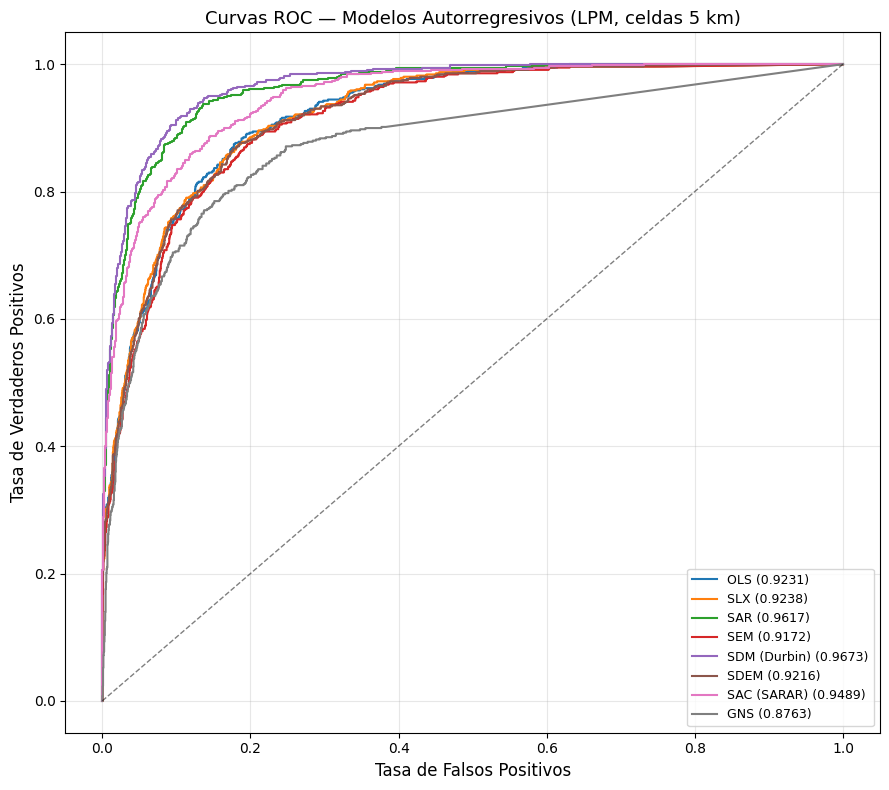

In [16]:
fig, ax = plt.subplots(figsize=(9, 8))
for res in resultados:
    fpr, tpr, _ = roc_curve(y.flatten(), res['prob'])
    ax.plot(fpr, tpr, label=f'{res["nombre"]} ({res["auc"]:.4f})', linewidth=1.5)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curvas ROC — Modelos Autorregresivos (LPM, celdas 5 km)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '02_curvas_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

### Matrices de confusión

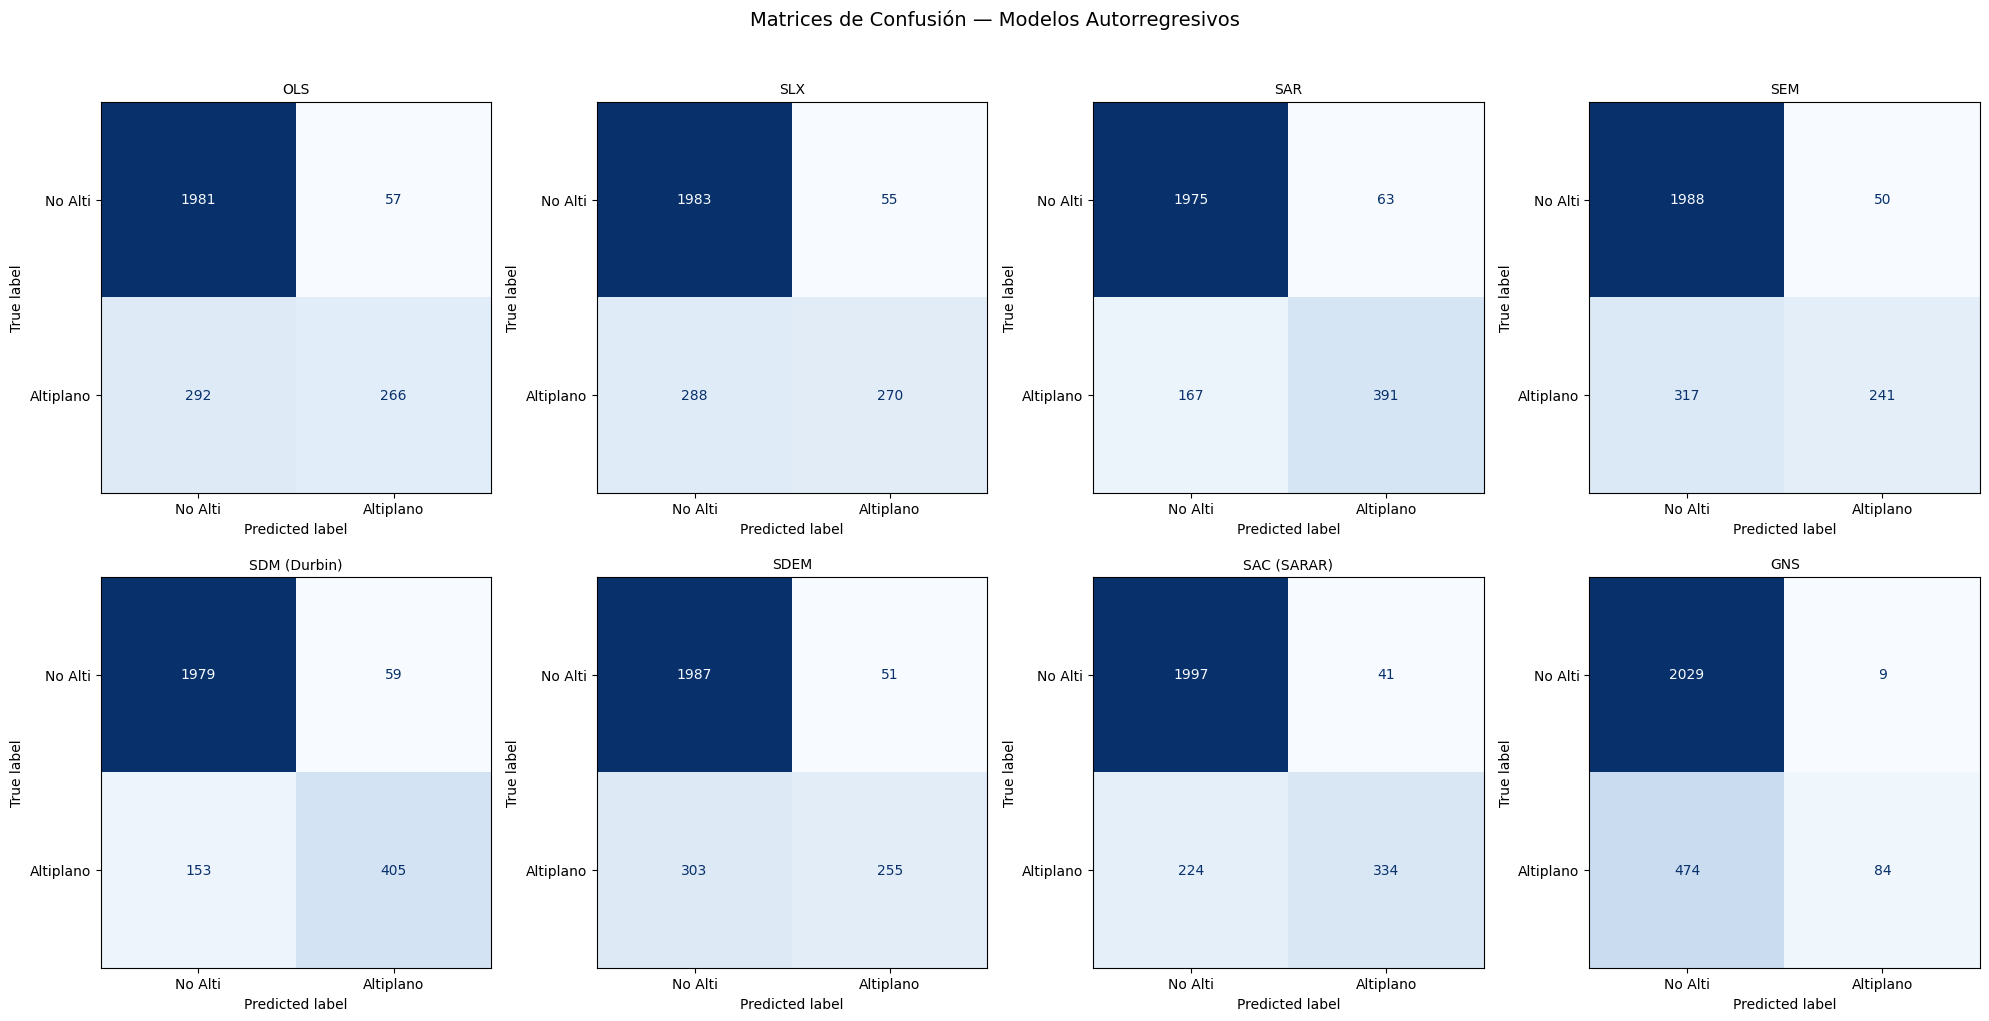

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for i, res in enumerate(resultados):
    pred_class = (res['prob'] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y.flatten(), pred_class,
        display_labels=['No Alti', 'Altiplano'],
        ax=axes_flat[i], cmap='Blues', colorbar=False)
    axes_flat[i].set_title(res['nombre'], fontsize=10)

plt.suptitle('Matrices de Confusión — Modelos Autorregresivos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '03_matrices_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Mapas de predicción

Grilla 3×3: el panel superior izquierdo muestra el Altiplano observado; los 8 restantes
muestran la probabilidad predicha por cada modelo (LPM, recortada a [0,1]).

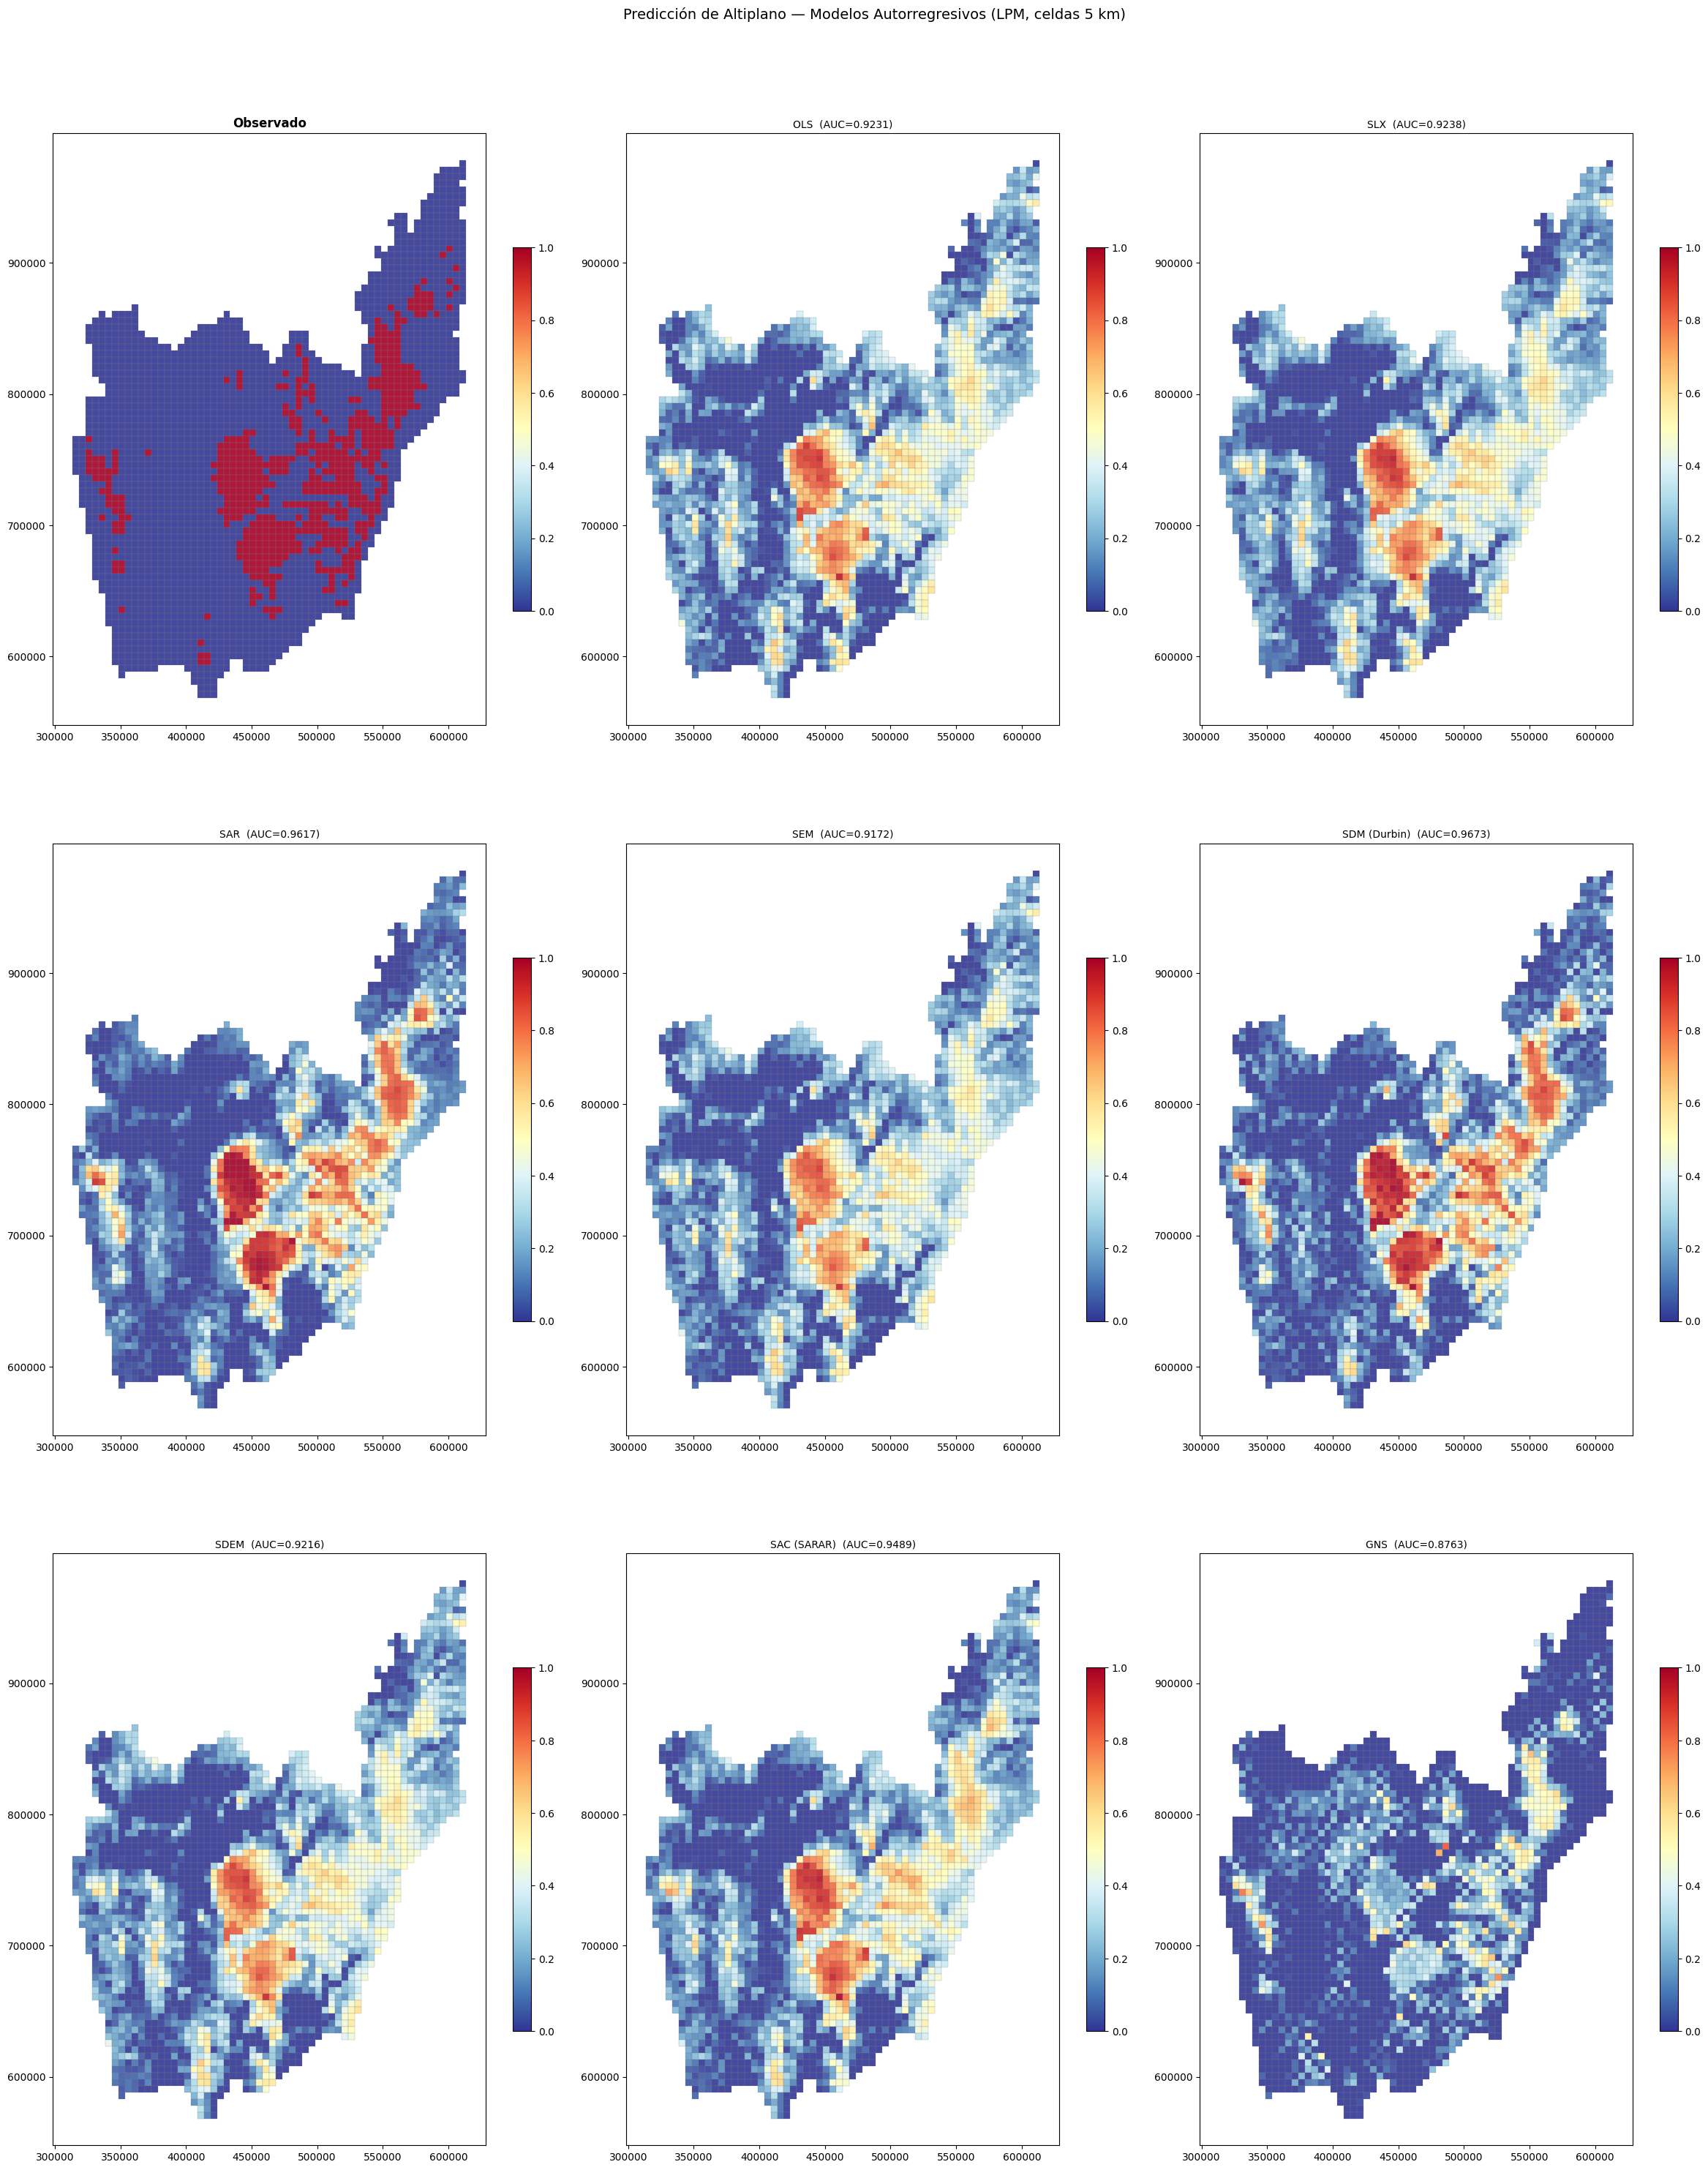

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(24, 30))

ax = axes[0, 0]
gdf.plot(column='y', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
         linewidth=0.2, alpha=0.9, legend=True,
         legend_kwds={'shrink': 0.5})
ax.set_title('Observado', fontsize=12, fontweight='bold')
ax.set_aspect('equal')

for i, res in enumerate(resultados):
    row_i, col_i = divmod(i + 1, 3)
    ax = axes[row_i, col_i]
    gdf_tmp = gdf.copy()
    gdf_tmp['prob'] = res['prob']
    gdf_tmp.plot(column='prob', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
                 linewidth=0.2, alpha=0.9, vmin=0, vmax=1, legend=True,
                 legend_kwds={'shrink': 0.5})
    ax.set_title(f'{res["nombre"]}  (AUC={res["auc"]:.4f})', fontsize=10)
    ax.set_aspect('equal')

plt.suptitle('Predicción de Altiplano — Modelos Autorregresivos (LPM, celdas 5 km)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '04_mapas_prediccion.png'), dpi=150, bbox_inches='tight')
plt.show()

### Mapas con plantilla cartográfica — Mejor modelo

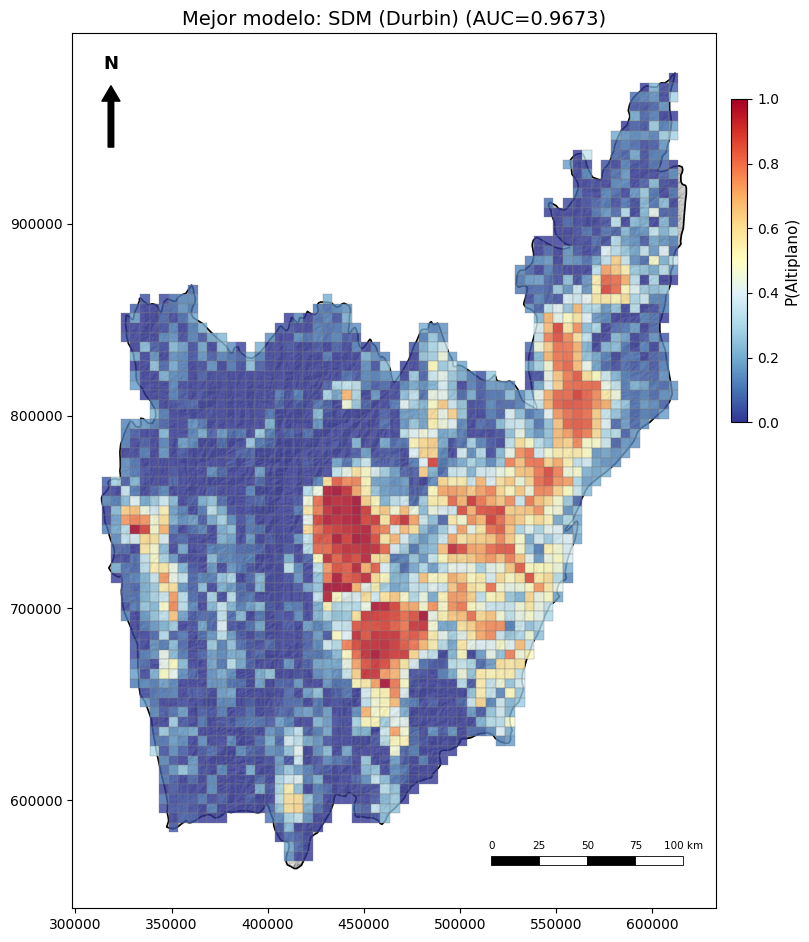

Mapa del mejor modelo (SDM (Durbin)) guardado


In [19]:
best_idx = df_comp['auc'].idxmax()
best_res = resultados[best_idx]

gdf_plot = gdf.copy()
gdf_plot['prob_best'] = best_res['prob']

fig, ax = plt.subplots(figsize=(10, 12))
ancla = aplicar_plantilla_mapa(ax)
gdf_plot.plot(column='prob_best', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
              linewidth=0.3, alpha=0.8, vmin=0, vmax=1, zorder=5,
              legend=False)
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0, 1))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.35, aspect=20, pad=0.02,
                    anchor=(0.0, 0.85))
cbar.set_label('P(Altiplano)', fontsize=11)
ax.set_title(f'Mejor modelo: {best_res["nombre"]} (AUC={best_res["auc"]:.4f})', fontsize=14)
plt.savefig(os.path.join(RES_DIR, '05_mapa_plantilla_mejor.png'),
            dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(IMG_DIR, '05_mapa_plantilla_mejor.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa del mejor modelo ({best_res["nombre"]}) guardado')

## 16. Exportación de resultados

GeoPackage con las probabilidades predichas de cada modelo, más la clasificación del
mejor modelo (umbral=0.5).

In [20]:
col_map = {
    'OLS': 'prob_ols', 'SLX': 'prob_slx', 'SAR': 'prob_sar',
    'SEM': 'prob_sem', 'SDM (Durbin)': 'prob_sdm', 'SDEM': 'prob_sdem',
    'SAC (SARAR)': 'prob_sac', 'GNS': 'prob_gns'
}

gdf_out = gdf[['y', 'altitud', 'pendiente', 'relieve', 'region', 'geometry']].copy()

for res in resultados:
    cname = col_map.get(res['nombre'], 'prob_' + res['nombre'].lower()[:6])
    gdf_out[cname] = res['prob']

best_idx = df_comp['auc'].idxmax()
gdf_out['pred_best'] = (resultados[best_idx]['prob'] >= 0.5).astype(int)
gdf_out['modelo_best'] = resultados[best_idx]['nombre']

out_path = os.path.join(BASE, 'Resultados', 'autorregresivos_areales_v2.gpkg')
gdf_out.to_file(out_path, driver='GPKG')
print(f'GeoPackage exportado: {out_path}')
print(f'  Registros: {len(gdf_out):,}')
print(f'  Columnas: {list(gdf_out.columns)}')

GeoPackage exportado: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\autorregresivos_areales_v2.gpkg
  Registros: 2,596
  Columnas: ['y', 'altitud', 'pendiente', 'relieve', 'region', 'geometry', 'prob_ols', 'prob_slx', 'prob_sar', 'prob_sem', 'prob_sdm', 'prob_sdem', 'prob_sac', 'prob_gns', 'pred_best', 'modelo_best']


In [21]:
print('\n' + '=' * 80)
print('  RESUMEN FINAL — Modelos Autorregresivos Areales')
print('=' * 80)

cols_final = ['nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'aic']
print(df_comp[cols_final].to_string(
    index=False,
    float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.1f}',
    na_rep='—'))

print(f'\nMejor modelo por AUC: {best_auc["nombre"]} (AUC={best_auc["auc"]:.4f})')
if len(df_ml) > 0:
    print(f'Mejor modelo por AIC: {best_aic["nombre"]} (AIC={best_aic["aic"]:.1f})')

print(f'\nArchivos generados:')
for f in sorted(os.listdir(RES_DIR)):
    if not f.startswith('_'):
        fpath = os.path.join(RES_DIR, f)
        sz = os.path.getsize(fpath)
        print(f'  {f} ({sz/1024:.0f} KB)')
print(f'  autorregresivos_areales_v2.gpkg')


  RESUMEN FINAL — Modelos Autorregresivos Areales
      nombre    auc  accuracy     f1  precision  recall    aic
         OLS 0.9231    0.8656 0.6039     0.8235  0.4767 1523.4
         SLX 0.9238    0.8679 0.6116     0.8308  0.4839 1515.5
         SAR 0.9617    0.9114 0.7727     0.8612  0.7007  749.4
         SEM 0.9172    0.8586 0.5677     0.8282  0.4319  703.9
SDM (Durbin) 0.9673    0.9183 0.7926     0.8728  0.7258  704.3
        SDEM 0.9216    0.8636 0.5903     0.8333  0.4570  701.6
 SAC (SARAR) 0.9489    0.8979 0.7160     0.8907  0.5986      —
         GNS 0.8763    0.8139 0.2581     0.9032  0.1505      —

Mejor modelo por AUC: SDM (Durbin) (AUC=0.9673)
Mejor modelo por AIC: SDEM (AIC=701.6)

Archivos generados:
  00_histogramas.png (59 KB)
  01_mapa_celdas_altiplano.png (811 KB)
  02_curvas_roc.png (127 KB)
  03_matrices_confusion.png (95 KB)
  04_mapas_prediccion.png (727 KB)
  05_mapa_plantilla_mejor.png (797 KB)
  metricas_autorregresivos.csv (1 KB)
  autorregresivos_areales_v